In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score)

from regression_and_hyperplain import z_plane

sb.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY="#004BA0"
GOLD="#D1AB3E"

In [2]:
df= pd.read_csv("IPLPlayerStat.csv")
if "Unnamed: 0" in df.columns:
    df=df.drop(columns=["Unnamed: 0"])
print("shape: ",df.shape)
df.head()

shape:  (605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [4]:
df["balls_faced"].describe()

count     605.000000
mean      373.477686
std       764.432561
min         1.000000
25%        18.000000
50%        73.000000
75%       285.000000
max      5266.000000
Name: balls_faced, dtype: float64

In [5]:
print(df.isnull().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


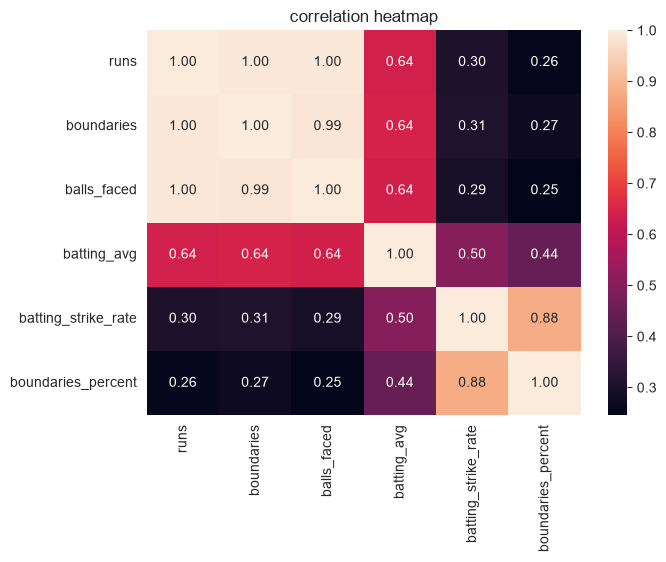

In [6]:
cols=["runs","boundaries","balls_faced","batting_avg","batting_strike_rate","boundaries_percent"]
plt.figure(figsize=(7,5))
sb.heatmap(df[cols].corr(),annot=True,fmt=".2f")
plt.title("correlation heatmap")
plt.show()

In [10]:
x=df[["balls_faced"]]
y=df["runs"]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
model=LinearRegression()
model.fit(x_train,y_train)
print("intercept: ",round(model.intercept_,2))
print("slope: ",round(model.coef_[0],4))

intercept:  -15.33
slope:  1.2844


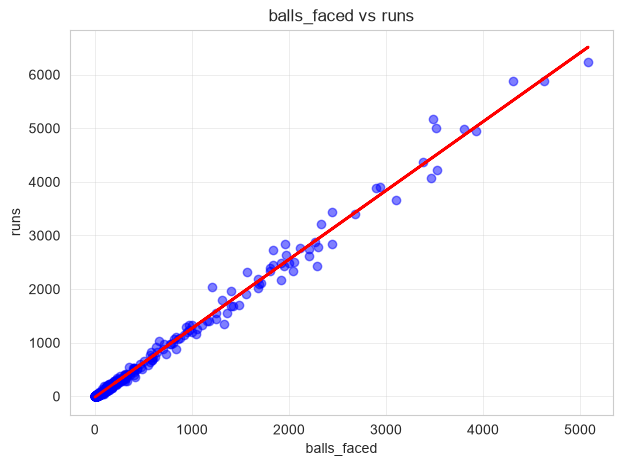

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(x_train,y_train,color="blue",alpha=0.5,label="training data")
plt.plot(x_train,model.predict(x_train),color="red",label="regression line",linewidth=2)
plt.xlabel("balls_faced")
plt.ylabel("runs")
plt.title("balls_faced vs runs")
plt.show()

In [13]:
y_pred=model.predict(x_test)
comparison=pd.DataFrame({
    "balls_faced": x_test["balls_faced"].values,
    "actual_runs": y_test.values,
    "predicted_runs": np.round(y_pred,2)
})
comparison.head(10)

,balls_faced,actual_runs,predicted_runs
0,434,522,542.09
1,27,40,19.35
2,57,76,57.88
3,31,21,24.48
4,552,663,693.64
5,865,985,1095.65
6,26,34,18.06
7,9,12,-3.77
8,18,20,7.79
9,703,920,887.58


In [15]:
new_players=pd.DataFrame({"balls_faced":[100,300,200]})
new_preds=model.predict(new_players)
for balls,runs in zip(new_players["balls_faced"],new_preds):
    print(f"balls_faced ={balls}->predicted runs ={runs:.0f}")

balls_faced =100->predicted runs =113
balls_faced =300->predicted runs =370
balls_faced =200->predicted runs =242


In [17]:
features=["balls_faced","boundaries"]
x_multi=df[features]
y_multi=df["runs"]
x_train_m,x_test_m,y_train_m,y_test_m=train_test_split(x_multi,y_multi,random_state=42,test_size=0.2)

multi_model=LinearRegression()
multi_model.fit(x_train_m,y_train_m)

print("intercept: ",round(multi_model.intercept_,2))
print("slope: ",multi_model.coef_)

intercept:  -3.83
slope:  [0.6870317 3.5314414]


In [19]:
y_pred_multi=multi_model.predict(x_test_m)
pd.DataFrame({
    "actual":y_test_m.values[:10],
    "predicted":y_pred_multi[:10]
})

,actual,predicted
0,522,513.295374
1,40,35.912753
2,76,70.649470
3,21,24.535114
4,663,650.868177
5,985,993.040990
6,34,31.694280
7,12,5.888975
8,20,15.603702
9,920,871.147530


In [25]:
import plotly.graph_objects as go
intercept=-3.83
coef={
    "balls_faced":0.6870,
    "boundaries":3.5314
}
def predict(balls_faced,boundaries):
    return(
        intercept+coef["balls_faced"]*balls_faced+coef["boundaries"]*boundaries
    )
x_feature="balls_faced"
y_feature="boundaries"

x=np.linspace(df[x_feature].min(),df[x_feature].max(),50)
y=np.linspace(df[y_feature].min(),df[y_feature].max(),50)

x_plane,y_plane=np.meshgrid(x,y)
z_plane=predict(x_plane,y_plane)

df["predicted"]=predict(df["balls_faced"],df["boundaries"])
fig=go.Figure()
fig.add_trace(go.Surface(x=x_plane,y=y_plane,z=z_plane,colorscale="Viridis",opacity=0.75,name="regression surface",showscale=True))
fig.add_trace(go.Scatter3d(
    x=df[x_feature],
    y=df[y_feature],
    z=df["predicted"],
    mode="markers",
    marker=dict(
        size=5,
        color="red"
    ),
    text=df["player"],
    hovertemplate=
    "<b>%{text}</b><br>"+
    f"{x_feature.replace('_',' ').title()}: %{{x: .2f}}<br>"+
    f"{y_feature.replace('_',' ').title()}: %{{x}}<br>"+
    "prediction: %{z: .2f}<extra></extra>",
    name="players"
))
fig.update_layout(
    title="multiple linear regression surface",
    scene=dict(
        xaxis_title=x_feature.replace('_',' ').title(),
        yaxis_title=y_feature.replace('_',' ').title(),
        zaxis_title="predicted value"
    ),
    width=1000,
    height=750
)
fig.show()

In [27]:
def adjusted_r2(r2,n,p):
    return 1-(1-r2)*(n-1)/(n-p-1)
def evaluate(name,y_true,y_pred,n_features):
    mae=mean_absolute_error(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=root_mean_squared_error(y_true,y_pred)
    r2=r2_score(y_true,y_pred)
    adj_r2=adjusted_r2(r2,len(y_true),n_features)

    print(f"----------{name}----------")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")
    print(f"adjusted R2: {adj_r2:.2f}\n")
    return {"model":name,"MAE":mae,"MSE":mse,"RMSE":rmse,"R2":r2,"adj_r2":adj_r2}
result=[]
result.append(evaluate("simple linear regression",y_test,y_pred,n_features=1))
result.append(evaluate("multiple linear regression",y_test_m,y_pred_multi,n_features=14))

----------simple linear regression----------
MAE: 33.81
MSE: 3246.97
RMSE: 56.98
R2: 0.9968
adjusted R2: 1.00

----------multiple linear regression----------
MAE: 18.08
MSE: 1450.77
RMSE: 38.09
R2: 0.9986
adjusted R2: 1.00

